In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

print(X.shape)
print(X[:5])

(150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [3]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

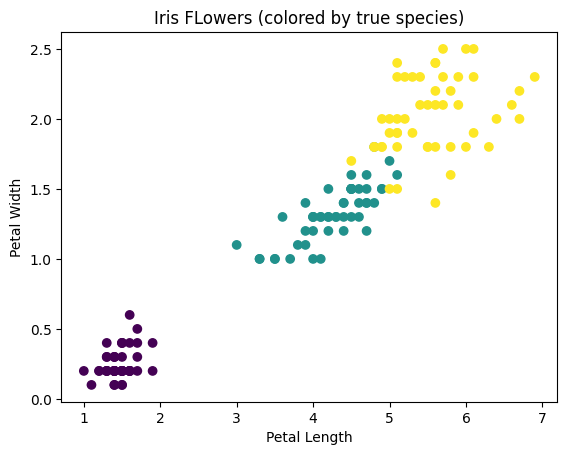

In [4]:
plt.scatter(X[:,2], X[:,3], c=y)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris FLowers (colored by true species)")
plt.show()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


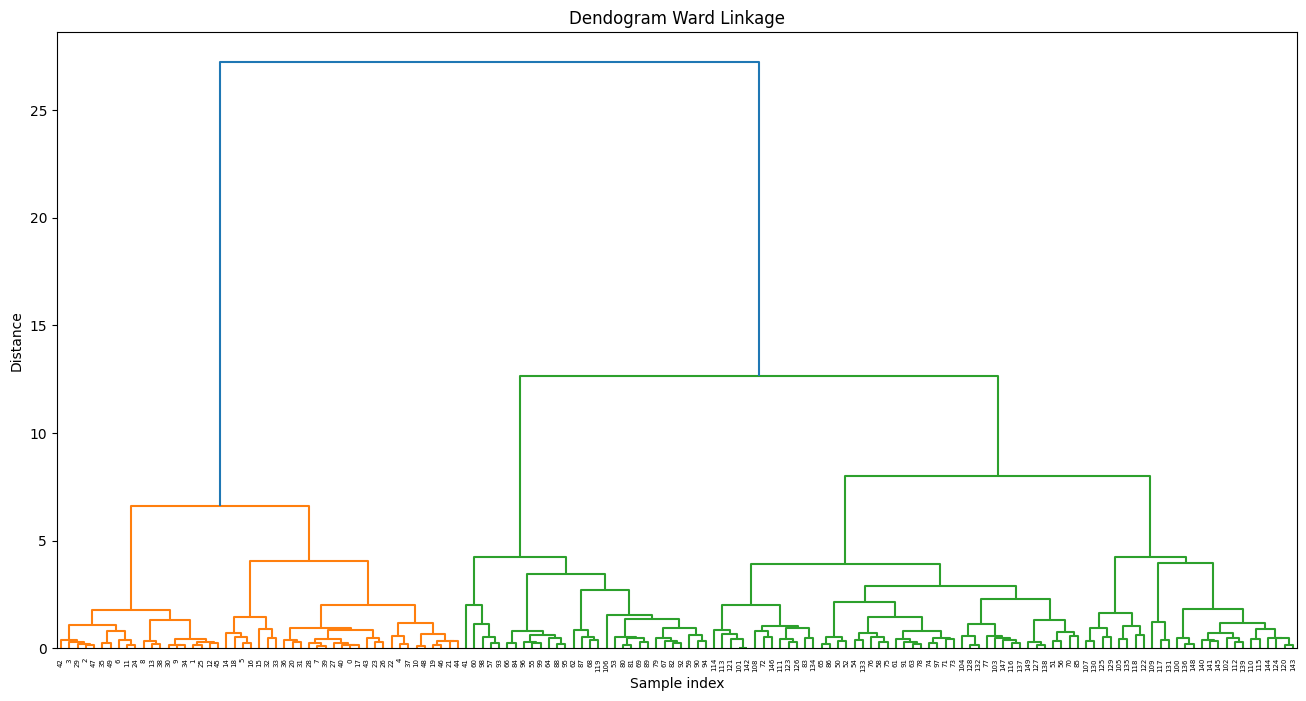

In [8]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(16,8))
dendrogram(Z)
plt.title("Dendogram Ward Linkage")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

In [9]:
model = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels = model.fit_predict(X_scaled)
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 0 2 0 2 0 2 2 2 2 0 0 0 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 2 2 2 2 0 2 2 2 2 2 0 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


Text(0.5, 1.0, 'Clustered')

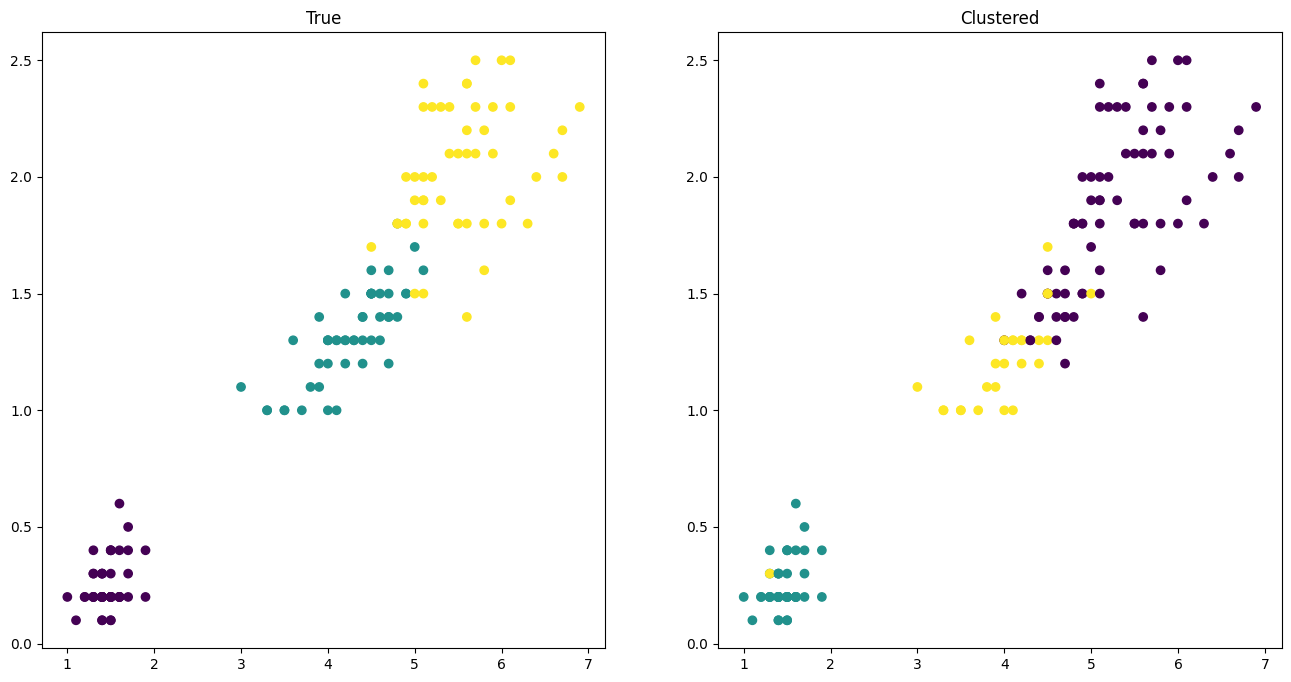

In [12]:
fig, axes = plt.subplots(1,2,figsize = (16,8))
axes[0].scatter(X[:,2], X[:,3], c=y)
axes[0].set_title("True")
axes[1].scatter(X[:,2], X[:,3], c=labels)
axes[1].set_title("Clustered")